In [ ]:
import sys, torch
print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU not enabled")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [ ]:
!pip install -q git+https://github.com/PatBall1/detectree2.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 74.8 MB/s eta 0:00:00


In [ ]:
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.1/163.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 11.9 MB/s eta 0:00:00


In [ ]:
import detectron2
import detectree2
print("imported successfully")

imported successfully


In [ ]:
!pip install -q rasterio geopandas shapely pyproj fiona opencv-python-headless matplotlib pandas

In [ ]:
!pip show detectree2
!pip show detectron2
!python -c "import detectree2; print(detectree2.__file__)"

Name: detectree2
Version: 2.1.2
Summary: Automatic tree crown delineation in aerial RGB imagery based on Mask R-CNN.
Home-page: https://github.com/PatBall1/detectree2
Author: 
Author-email: "James G. C. Ball" <ball.jgc@gmail.com>
License: MIT
Location: /usr/local/lib/python3.13/dist-packages
Requires: fiona, geopandas, numpy, opencv-python, pandas, pycocotools, pyyaml, rasterio, rtree, shapely, tqdm
Required-by: 
Name: detectron2
Version: 0.6
Summary: Detectron2 is FAIR's next-generation research platform for object detection and segmentation.
Home-page: https://github.com/facebookresearch/detectron2
Author: FAIR
Author-email: 
License: 
Location: /usr/local/lib/python3.13/dist-packages
Requires: black, cloudpickle, fvcore, hydra-core, iopath, matplotlib, omegaconf, packaging, Pillow, pycocotools, tabulate, tensorboard, termcolor, tqdm, yacs
Required-by: 
/usr/local/lib/python3.13/dist-packages/detectree2/__init__.py


In [ ]:
import os
os.makedirs("data", exist_ok=True)
url = "https://github.com/opengeos/datasets/releases/download/samgeo/tree_image.tif"
!wget -q -O data/test.tif "$url"
print("File size:", os.path.getsize("data/test.tif") / 1024**2, "MB")

File size: 3.931473731994629 MB


Width: 1976
Height: 1087
Bands: 3
CRS: EPSG:3857
Resolution: (0.29857960587267496, 0.29859465645264627)


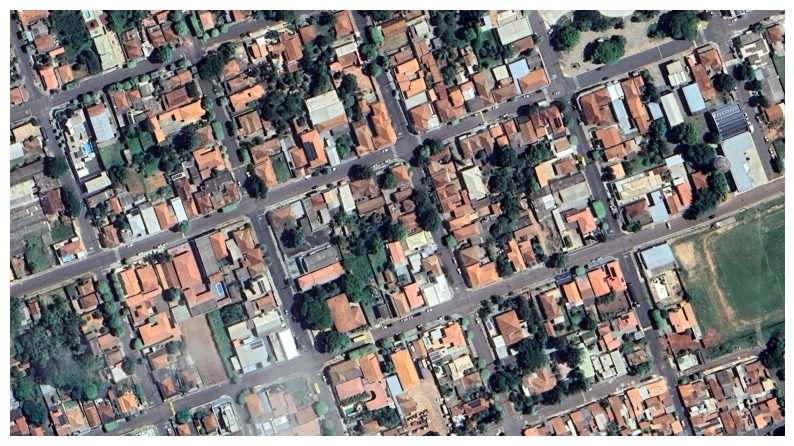

In [ ]:
import rasterio
import matplotlib.pyplot as plt
with rasterio.open("data/test.tif") as src:
    img = src.read()
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("CRS:", src.crs)
    print("Resolution:", src.res)
rgb = img[:3].transpose(1, 2, 0)
plt.figure(figsize=(10, 8))
plt.imshow(rgb)
plt.axis("off");

In [ ]:
# %pip install -q -U segment-geospatial

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.2/157.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 11.3 MB/s eta 0:00:00


In [ ]:
import samgeo
print("samgeo:", samgeo.__file__)
from samgeo.detectree2 import TreeCrownDelineator, list_pretrained_models
print("Detectree2 wrapper loaded")
print("Available models:")
for name in list_pretrained_models():
    print("-", name)

samgeo: /usr/local/lib/python3.13/dist-packages/samgeo/__init__.py
Detectree2 wrapper loaded
Available models:
- paracou
- sepilok
- danum
- default


In [ ]:
# from samgeo.detectree2 import TreeCrownDelineator
# delineator = TreeCrownDelineator(
#    model_name="default",
 #   confidence_threshold=0.5,
  #  nms_threshold=0.3,)
# print("🌳 Tree crown model ready")

Downloading...
From: https://zenodo.org/records/15863800/files/250312_flexi.pth
To: /root/.cache/detectree2/250312_flexi.pth
100%|██████████| 763/763 [00:00<00:00, 2.49MB/s]

🌳 Tree crown model ready


In [ ]:
import torch
# Compatibility fix for PyTorch >= 2.6 with older Detectron2 checkpoints
_original_torch_load = torch.load
def torch_load_compat(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _original_torch_load(*args, **kwargs)
torch.load = torch_load_compat
print("PyTorch checkpoint compatibility fix applied")

PyTorch checkpoint compatibility fix applied


In [ ]:
import os
import requests

url = "https://zenodo.org/records/15863800/files/250312_flexi.pth"
path = "/content/250312_flexi.pth"

r = requests.get(url, allow_redirects=True)

print("Status:", r.status_code)
print("Downloaded:", len(r.content), "bytes")
print("Final URL:", r.url)

open(path, "wb").write(r.content)

Status: 200
Downloaded: 503063232 bytes
Final URL: https://zenodo.org/records/15863800/files/250312_flexi.pth


503063232

In [ ]:
import os
size = os.path.getsize("/content/250312_flexi.pth")
print("Checkpoint size:", size, "bytes")
print("Checkpoint size:", round(size / 1024**2, 2), "MB")

Checkpoint size: 503063232 bytes
Checkpoint size: 479.76 MB


In [ ]:
# from samgeo.detectree2 import list_pretrained_models
# models = list_pretrained_models()
# for name, url in models.items():
#     print(name)
#     print(url)
#     print()

paracou
https://zenodo.org/records/15863800/files/250312_flexi.pth

sepilok
https://zenodo.org/records/10522461/files/230103_randresize_full.pth

danum
https://zenodo.org/records/10522461/files/230103_randresize_full.pth

default
https://zenodo.org/records/15863800/files/250312_flexi.pth



In [ ]:
from samgeo.detectree2 import TreeCrownDelineator
delineator = TreeCrownDelineator(
    model_path="/content/250312_flexi.pth",
    device="cuda",
    confidence_threshold=0.5,
    nms_threshold=0.3)
print("🌳 Model loaded successfully!")

🌳 Model loaded successfully!


In [ ]:
output_path = "data/tree_crowns.gpkg"
crowns = delineator.predict(
    image_path="data/test.tif",
    output_path=output_path,
    tile_width=20,
    tile_height=20,
    buffer=30,
    simplify_tolerance=0.2,
    min_confidence=0.3,
    iou_threshold=0.6,)
print("🌳 Trees detected:", len(crowns))
print("Saved to:", output_path)

/usr/local/lib/python3.13/dist-packages/detectron2/model_zoo/model_zoo.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


  0%|          | 0/338 [00:00<?, ?it/s]

Predicting files in mode rgb:   0%|          | 0/338 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0913 02:13:37.878000 1631 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
Stitching crowns: 100%|██████████| 338/338 [00:03<00:00, 110.42file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 8970/8970 [00:00<00:00, 11978.48it/s]


🌳 Trees detected: 137
Saved to: data/tree_crowns.gpkg


In [ ]:
print("Shape:", crowns.shape)
print("Columns:", list(crowns.columns))
display(crowns.head())

Shape: (137, 2)
Columns: ['Confidence_score', 'geometry']


,Confidence_score,geometry
0,0.846943,"POLYGON ((-5705725.51 -2532762.129, -5705725.8..."
1,0.957606,"POLYGON ((-5705789.406 -2532832.896, -5705790...."
2,0.951946,"POLYGON ((-5705768.804 -2532782.732, -5705770...."
3,0.954143,"POLYGON ((-5705758.055 -2532814.681, -5705759...."
4,0.929366,"POLYGON ((-5705764.027 -2532790.495, -5705766...."


In [ ]:
print("CRS:", crowns.crs)
print("Geometry types:")
print(crowns.geometry.geom_type.value_counts())

CRS: EPSG:3857
Geometry types:
Polygon    137
Name: count, dtype: int64


In [ ]:
crowns["area_m2"] = crowns.geometry.area
print("🌳 Trees detected :", len(crowns))
print("🌿 Total canopy  :", round(crowns["area_m2"].sum(), 2), "m²")
print("📏 Mean crown    :", round(crowns["area_m2"].mean(), 2), "m²")
print("📊 Median crown  :", round(crowns["area_m2"].median(), 2), "m²")

🌳 Trees detected : 137
🌿 Total canopy  : 9421.33 m²
📏 Mean crown    : 68.77 m²
📊 Median crown  : 55.32 m²


In [ ]:
with rasterio.open("data/test.tif") as src:
    print("dtype:", src.dtypes)
    print("min:", src.read().min())
    print("max:", src.read().max())
    print("nodata:", src.nodata)
    print("bands:", src.count)

dtype: ('uint8', 'uint8', 'uint8')
min: 0
max: 255
nodata: None
bands: 3


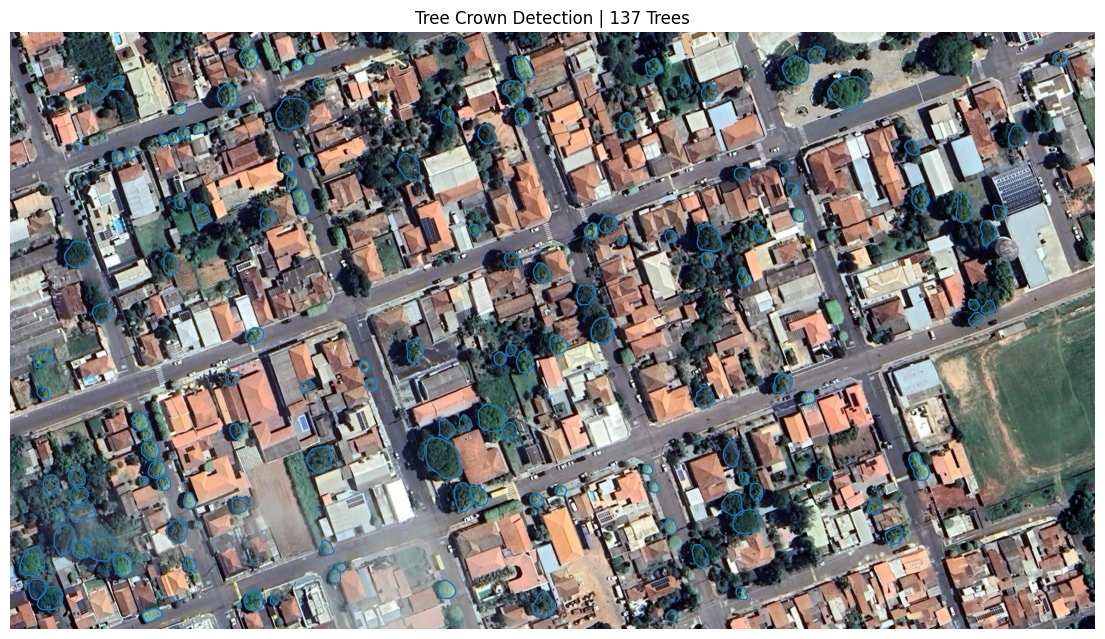

In [ ]:
from rasterio.plot import plotting_extent
with rasterio.open("data/test.tif") as src:
    rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
    extent = plotting_extent(src)
fig, ax = plt.subplots(figsize=(14, 9))
ax.imshow(rgb, extent=extent)
crowns.boundary.plot(ax=ax, linewidth=1)
ax.set_title(f"Tree Crown Detection | {len(crowns)} Trees")
ax.set_axis_off()
plt.show()

In [ ]:
results = crowns.copy()
results["tree_id"] = range(1, len(results) + 1)
results = results.rename(columns={"Confidence_score": "confidence"})
results["area_m2"] = results.geometry.area
display(
    results[["tree_id", "confidence", "area_m2"]]
    .sort_values("tree_id").head(10))

,tree_id,confidence,area_m2
0,1,0.846943,39.004995
1,2,0.957606,102.126222
2,3,0.951946,68.604214
3,4,0.954143,102.616570
4,5,0.929366,45.646989
5,6,0.843140,75.379939
6,7,0.729689,140.819177
7,8,0.661134,72.304117
8,9,0.643946,34.993053
9,10,0.652153,75.335362


In [ ]:
csv_path = "data/tree_detections.csv"
results[["tree_id", "confidence", "area_m2"]].to_csv(
    csv_path,
    index=False
)
print("CSV saved:", csv_path)

CSV saved: data/tree_detections.csv


In [ ]:
! pip install -q gradio

In [ ]:
from rasterio.plot import plotting_extent

def analyze(image_path):
    crowns = delineator.predict(
        image_path=image_path,
        output_path="data/app_crowns.gpkg",
        tile_width=20,
        tile_height=20,
        buffer=30,
        simplify_tolerance=0.2,
        min_confidence=0.3,
        iou_threshold=0.6,
    )

    crowns["area_m2"] = crowns.geometry.area

    results = crowns[["Confidence_score", "area_m2"]].copy()
    results.insert(0, "tree_id", range(1, len(results) + 1))
    results = results.rename(columns={"Confidence_score": "confidence"})

    csv_path = "data/tree_detections.csv"
    results.to_csv(csv_path, index=False)

    with rasterio.open(image_path) as src:
        rgb = src.read([1, 2, 3]).transpose(1, 2, 0)
        extent = plotting_extent(src)

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(rgb, extent=extent)
    crowns.boundary.plot(ax=ax, linewidth=1)
    ax.set_title(f"Tree Crown Detection | {len(crowns)} Trees")
    ax.set_axis_off()
    plt.tight_layout()

    summary = (
        f"🌳 Trees detected: {len(crowns)}\n\n"
        f"🌿 Total crown area: {crowns.area_m2.sum():,.2f} m²\n\n"
        f"📏 Mean crown area: {crowns.area_m2.mean():,.2f} m²\n\n"
        f"📊 Median crown area: {crowns.area_m2.median():,.2f} m²"
    )

    return fig, summary, results, csv_path


app.close()

app = gr.Interface(
    fn=analyze,
    inputs=gr.File(
        label="Upload high-resolution GeoTIFF",
        file_types=[".tif", ".tiff"],
        type="filepath"
    ),
    outputs=[
        gr.Plot(label="Detected Tree Crowns"),
        gr.Textbox(label="Results"),
        gr.Dataframe(label="Individual Trees"),
        gr.File(label="Download CSV")
    ],
    title="🌳 COUNT THE TREES AI",
    description="Upload high-resolution forest imagery to detect and count individual tree crowns and estimate their crown footprint area.",
    flagging_mode="never"
)

app.launch(share=True)

Closing server running on port: 7860
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://325efbc22da8f2a983.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
